In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [59]:
def segment_image(image, label):
    # gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    # mask = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C, 
    #                             cv2.THRESH_BINARY, 45, 2)
    # # mask = cv2.erode(mask, None, iterations=2)
    # mask = cv2.dilate(mask, None, iterations=2)
    # mask = cv2.erode(mask, None, iterations=1)
    # mask = cv2.bitwise_not(mask)
    # result = cv2.bitwise_and(image, image, mask=mask)
    
    nmax = 255 #New maximum
    nmin = 0 #New minimum
    out = cv2.normalize(image,None,alpha = nmin,beta = nmax,norm_type = cv2.NORM_MINMAX)
    
    hsv_img = cv2.cvtColor(out, cv2.COLOR_BGR2HSV)
    
    mask = np.zeros(image.shape[:2], np.uint8)
    bgModel = np.zeros((1, 65), np.float64)
    fgModel = np.zeros((1, 65), np.float64)

    # Rectangle awal perkiraan daun
    rect = (1, 1, 225, 225)
    cv2.grabCut(image, mask, rect, bgModel, fgModel, 8, cv2.GC_INIT_WITH_RECT)

    mask2 = np.where((mask == 2) | (mask == 0), 0, 1).astype("uint8")
    
    fig = plt.figure(figsize=(9, 6))

    plt.axis('off') 
    plt.title(label)
    plt.imshow(cv2.cvtColor(mask2*255, cv2.COLOR_BGR2RGB))
    
    lower_yellow = np.array([ 0, 100, 0])  # Adjust as needed
    upper_yellow = np.array([27, 255, 255])  # Adjust as
    
    # lower_chocolate = np.array([0, 10, 0])
    # upper_chocolate = np.array([15, 255, 255])
    
    yellow_mask = cv2.inRange(hsv_img, lower_yellow, upper_yellow)
    # dark_chocolate_mask = cv2.inRange(hsv_img, lower_chocolate, upper_chocolate)
    
    # mask3 = cv2.bitwise_or(yellow_mask, dark_chocolate_mask)
    # mask3 = yellow_mask
    
    contours, _ = cv2.findContours(yellow_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    mask_cleaned = np.zeros_like(yellow_mask)
    
    for contour in contours:
        area = cv2.contourArea(contour)
        if area > 60:
            # Isi area yang cukup besar
            cv2.drawContours(mask_cleaned, [contour], -1, 255, thickness=cv2.FILLED)
    kernel_close = np.ones((7, 7), np.uint8) # Gunakan kernel agak besar
    mask3 = cv2.morphologyEx(mask_cleaned, cv2.MORPH_CLOSE, kernel_close)
    
    # mask3 = cv2.dilate(mask3, None, iterations=2)
    # mask3 = cv2.erode(mask3, None, iterations=2)
    # mask3 = cv2.bitwise_and(mask3, mask3, mask=mask2)
    
    print(mask3.max(), image.shape)
    
    fig = plt.figure(figsize=(9, 6))

    plt.axis('off') 
    plt.title(label)
    plt.imshow(cv2.cvtColor(mask3, cv2.COLOR_BGR2RGB))
    
    # mask = cv2.erode(mask, None, iterations=2)
    # mask = cv2.dilate(mask, None, iterations=2)
    # mask = cv2.bitwise_not(mask)
    result = cv2.bitwise_and(image, image, mask=mask3)
    
    return result
    # return mask

(227, 227, 3)
255 (227, 227, 3)


Text(0.5, 1.0, 'brown_spot')

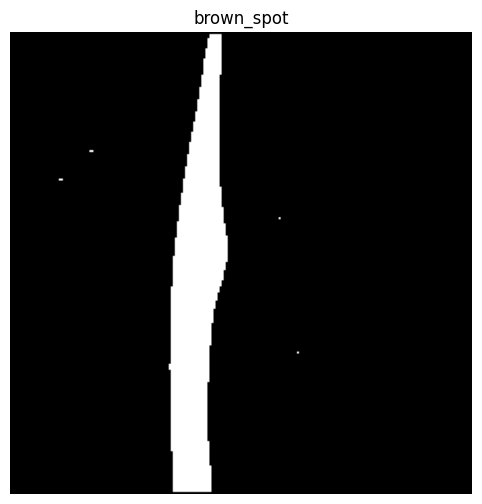

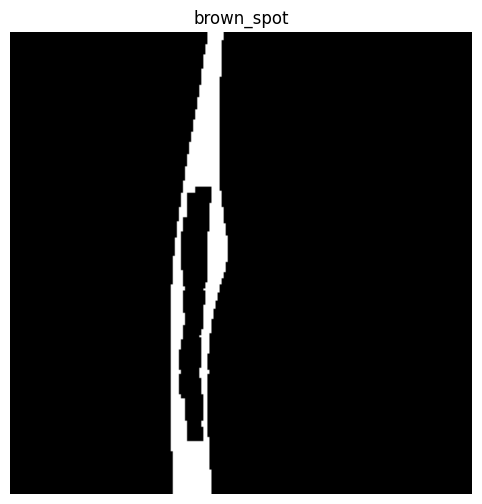

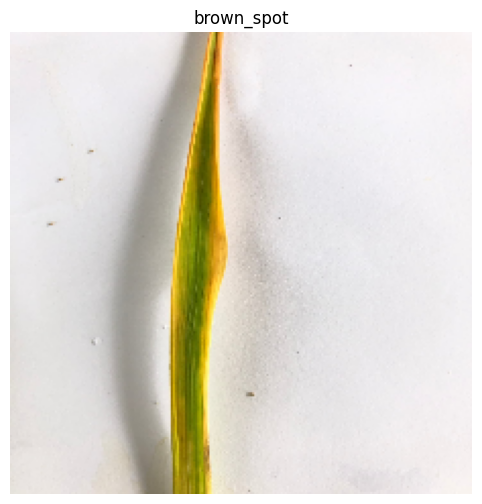

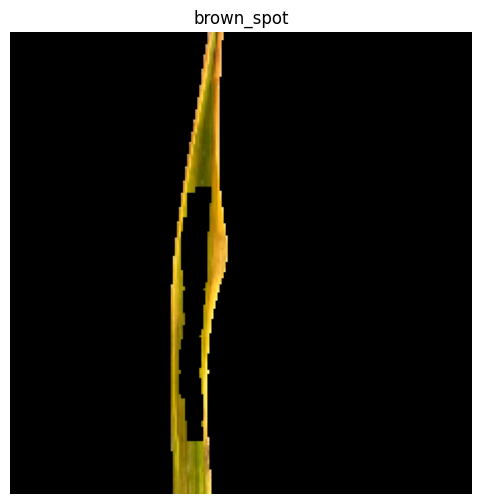

In [60]:
IMG_SIZE = (227, 227)
label = 'brown_spot'
img = cv2.resize(cv2.imread('datasets/leaf-rice-disease-indonesia/tungro/IMG_0400.jpg'), IMG_SIZE)
print(img.shape)
segment_image = segment_image(img, label)

fig = plt.figure(figsize=(9, 6))

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off') 
plt.title(label)

fig = plt.figure(figsize=(9, 6))

plt.imshow(cv2.cvtColor(segment_image, cv2.COLOR_BGR2RGB))
plt.axis('off') 
plt.title(label)